# SSD300 Complete Standalone Pipeline for Kaggle

This notebook contains everything needed to train and evaluate SSD300 on Pascal VOC 2012 dataset.
It's designed to run standalone in Kaggle without external dependencies.

## Features:
- Complete VOC to COCO conversion
- SSD300 training with enhanced logging
- Comprehensive evaluation with COCO metrics
- Visual comparisons of ground truth vs predictions
- Model checkpointing and visualization
- Comparison images testing from comparison_images.json

## 1. Setup and Imports

In [20]:
import os
import sys
import json
import xml.etree.ElementTree as ET
import logging
import argparse
from datetime import datetime
from pathlib import Path
import time
import random
import shutil

# Data handling
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont

# ML/DL libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display, clear_output

# COCO evaluation
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Configure matplotlib and seaborn
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [21]:
# ===== Shared benchmark_common bootstrap (P0) =====
# Locates the repo root (identified by benchmark_common/protocol.py) and adds
# it to sys.path so the shared evaluation/timing/dataset-conversion module is
# importable. If this notebook was imported standalone (e.g. via Kaggle's
# "Import Notebook" flow, which only pulls in the single .ipynb file, not the
# rest of the repo), benchmark_common won't exist anywhere on disk -- in that
# case this clones the repo (dev branch, where these files live) into
# /kaggle/working (or /content on Colab) and uses that as the repo root.
import sys
import subprocess
from pathlib import Path

_REPO_URL = 'https://github.com/nithin-pulla/object-detection-benchmarking-and-analysis.git'
_REPO_BRANCH = 'dev'  # benchmark_common currently only exists on dev, not main


def _find_repo_root():
    anchor = Path('benchmark_common') / 'protocol.py'
    candidates = [Path.cwd(), *Path.cwd().parents]
    candidates += [
        Path('/kaggle/working/object-detection-benchmarking-and-analysis'),
        Path('/kaggle/working'),
        Path('/content/object-detection-benchmarking-and-analysis'),
        Path('/content'),
    ]
    scanned = list(candidates)
    for c in candidates:
        try:
            scanned += [p for p in c.iterdir() if p.is_dir()]
        except (FileNotFoundError, NotADirectoryError, PermissionError):
            continue
    seen = set()
    for c in scanned:
        try:
            c = c.resolve()
        except OSError:
            continue
        if c in seen:
            continue
        seen.add(c)
        if (c / anchor).exists():
            return c
    return None


def _clone_repo_root():
    if Path('/kaggle/working').exists():
        dest = Path('/kaggle/working/object-detection-benchmarking-and-analysis')
    elif Path('/content').exists():
        dest = Path('/content/object-detection-benchmarking-and-analysis')
    else:
        dest = Path.cwd() / 'object-detection-benchmarking-and-analysis'

    if not (dest / 'benchmark_common' / 'protocol.py').exists():
        print(f"benchmark_common not found on disk -- cloning {_REPO_URL} ({_REPO_BRANCH}) into {dest} ...")
        result = subprocess.run(
            ['git', 'clone', '--depth', '1', '--branch', _REPO_BRANCH, _REPO_URL, str(dest)],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            raise FileNotFoundError(
                f"Could not locate 'benchmark_common/protocol.py' locally, and cloning "
                f"{_REPO_URL} failed:\n{result.stderr}\n"
                f"Clone the repo (branch '{_REPO_BRANCH}') yourself and set sys.path manually, e.g.:\n"
                f"    sys.path.insert(0, '{dest}')"
            )
    return dest


_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is None:
    _REPO_ROOT = _clone_repo_root()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print(f"benchmark_common resolved from: {_REPO_ROOT}")

from benchmark_common import protocol, seeding, voc_coco, eval_coco, speed_bench, comparison

seeding.set_global_seed(protocol.GLOBAL_SEED)
print(f"Global seed set to {protocol.GLOBAL_SEED} (P0: benchmark_common.seeding)")
print(f"Shared evaluation operating point: conf={protocol.CONF_THRESHOLD}, IoU={protocol.IOU_THRESHOLD}")


benchmark_common resolved from: /kaggle/working/object-detection-benchmarking-and-analysis
Global seed set to 42 (P0: benchmark_common.seeding)
Shared evaluation operating point: conf=0.25, IoU=0.5


In [22]:
# Ensure pycocotools is available (Kaggle validation fix). It is not listed
# in requirements.txt and Kaggle's base image doesn't guarantee it -- this
# was already an implicit dependency of the original notebook (COCOeval)
# and is now also required by benchmark_common.eval_coco.
try:
    import pycocotools
    print(f"pycocotools already available: {pycocotools.__file__}")
except ImportError:
    print("pycocotools not found -- installing...")
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pycocotools'], check=True)
    import pycocotools
    print("pycocotools installed")


pycocotools already available: /usr/local/lib/python3.12/dist-packages/pycocotools/__init__.py


In [23]:
# Capture the ACTUAL runtime environment (Kaggle validation fix):
# requirements.txt pins torch==2.7.1 / torchvision==0.22.1, but this
# notebook never runs `pip install -r requirements.txt` -- it imports
# whatever Kaggle's base image already provides. Recording the real
# versions here (rather than forcing a possibly CUDA-incompatible
# reinstall) keeps every run individually traceable/reproducible.
import subprocess as _subprocess


def _git_commit_hash(repo_root):
    try:
        result = _subprocess.run(
            ['git', 'rev-parse', 'HEAD'], cwd=str(repo_root),
            capture_output=True, text=True, check=True
        )
        return result.stdout.strip()
    except Exception:
        return 'unknown'


environment_info = {
    'python_version': sys.version,
    'torch_version': torch.__version__,
    'torchvision_version': torchvision.__version__,
    'cuda_version': torch.version.cuda,
    'cudnn_version': torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'repo_commit': _git_commit_hash(_REPO_ROOT),
    'repo_branch': _REPO_BRANCH,
    'global_seed': protocol.GLOBAL_SEED,
}

print("Environment info (recorded for reproducibility):")
for _k, _v in environment_info.items():
    print(f"   {_k}: {_v}")


Environment info (recorded for reproducibility):
   python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
   torch_version: 2.10.0+cu128
   torchvision_version: 0.25.0+cu128
   cuda_version: 12.8
   cudnn_version: 91002
   gpu_name: Tesla T4
   repo_commit: 9ed6727b7af7f618c07c34883606bfb1e13eb9f6
   repo_branch: dev
   global_seed: 42


In [24]:
# GPU/CUDA compatibility pre-flight check (Kaggle validation fix): a
# "CUDA error: no kernel image is available for execution on the device"
# during training means the installed torch build's compiled kernels don't
# cover this GPU's compute capability. Catch that here, before burning
# time on data prep/training, with an actionable message instead of a
# traceback three layers deep in torchvision's transform code.
if torch.cuda.is_available():
    _gpu_cap = torch.cuda.get_device_capability(0)
    _gpu_arch = f"sm_{_gpu_cap[0]}{_gpu_cap[1]}"
    _supported_archs = torch.cuda.get_arch_list()
    print(f"GPU: {torch.cuda.get_device_name(0)} (compute capability {_gpu_cap[0]}.{_gpu_cap[1]}, {_gpu_arch})")
    print(f"torch {torch.__version__} was built with kernels for: {_supported_archs}")
    if _gpu_arch not in _supported_archs:
        raise RuntimeError(
            f"This GPU's compute capability ({_gpu_arch}) is not in the set of "
            f"architectures torch {torch.__version__} was compiled for "
            f"({_supported_archs}). Training will fail with 'CUDA error: no "
            f"kernel image is available for execution on the device'.\n"
            f"Fix: in Kaggle's notebook Settings (right sidebar), change the "
            f"Accelerator to a different GPU option -- 'GPU T4 x2' is the most "
            f"broadly supported by Kaggle's stock PyTorch image -- then Factory "
            f"Reset the session and re-run from the top."
        )
else:
    print("WARNING: CUDA not available -- training will run on CPU (slow).")


GPU: Tesla T4 (compute capability 7.5, sm_75)
torch 2.10.0+cu128 was built with kernels for: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 2. Configuration and Global Variables

In [25]:
# ===== CONFIGURATION - MODIFY THESE PATHS FOR YOUR SETUP =====

# For Kaggle, update these paths to match your Kaggle setup
CONFIG = {
    # Dataset paths (modify for Kaggle)
    'voc_root': '/kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012',  # Kaggle input path (confirmed via FasterRCNN's Kaggle run; re-verify if this changes)
    'output_dir': '/kaggle/working/ssd300_outputs',  # Kaggle working directory
    
    # Training parameters
    'image_size': 300,
    'batch_size': 4,
    'num_epochs': 5,
    'learning_rate': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    
    # Evaluation parameters (P0: standardized via benchmark_common.protocol
    # -- must be identical across all three models for the primary comparison)
    'conf_threshold': protocol.CONF_THRESHOLD,
    'nms_threshold': protocol.IOU_THRESHOLD,
    
    # Experiment settings
    'experiment_name': f'ssd300_voc_{datetime.now().strftime("%Y%m%d_%H%M%S")}',
    'save_checkpoints': True,
    'checkpoint_every': 1,  # Save every N epochs
    'save_visualizations': True,
    'run_comparison_images': True
}

# VOC Classes
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(VOC_CLASSES)}
IDX_TO_CLASS = {idx: cls for idx, cls in enumerate(VOC_CLASSES)}

# Create output directories
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/models", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/logs", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/predictions", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/visualizations", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/data", exist_ok=True)

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print(f"\n📁 Output directory created: {CONFIG['output_dir']}")
print(f"🎯 Experiment name: {CONFIG['experiment_name']}")

Configuration:
  voc_root: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012
  output_dir: /kaggle/working/ssd300_outputs
  image_size: 300
  batch_size: 4
  num_epochs: 5
  learning_rate: 0.0001
  device: cuda
  num_workers: 2
  conf_threshold: 0.25
  nms_threshold: 0.5
  experiment_name: ssd300_voc_20260824_225830
  save_checkpoints: True
  checkpoint_every: 1
  save_visualizations: True
  run_comparison_images: True

📁 Output directory created: /kaggle/working/ssd300_outputs
🎯 Experiment name: ssd300_voc_20260824_225830


In [26]:
# Verify the dataset mount path BEFORE the expensive VOC->COCO conversion
# runs (Kaggle validation fix). Kaggle mounts an attached dataset at
# /kaggle/input/<dataset-slug>/..., and <dataset-slug> may not match the
# 'voc2012' this notebook assumes by default.
if not os.path.exists(CONFIG['voc_root']):
    _kaggle_input = Path('/kaggle/input')
    _available = sorted(p.name for p in _kaggle_input.iterdir()) if _kaggle_input.exists() else []
    raise FileNotFoundError(
        f"CONFIG['voc_root'] does not exist: {CONFIG['voc_root']}\n"
        f"Available datasets under /kaggle/input: {_available}\n"
        f"Update CONFIG['voc_root'] above to match the actual mounted path, "
        f"e.g. '/kaggle/input/<actual-slug>/VOCdevkit/VOC2012', then re-run "
        f"from the CONFIGURATION cell."
    )
else:
    print(f"VOC dataset found at: {CONFIG['voc_root']}")


VOC dataset found at: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012


## 3. Enhanced Logging Setup

In [27]:
# Setup comprehensive logging
log_file = f"{CONFIG['output_dir']}/logs/{CONFIG['experiment_name']}.log"

# Create custom logger
logger = logging.getLogger('SSD300_Pipeline')
logger.setLevel(logging.INFO)

# Clear existing handlers
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

# File handler
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.INFO)

# Console handler
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)

# Formatter
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

# Add handlers
logger.addHandler(file_handler)
logger.addHandler(console_handler)

# Training metrics tracking
training_metrics = {
    'start_time': None,
    'end_time': None,
    'epoch_times': [],
    'train_losses': [],
    'learning_rates': [],
    'best_map': 0.0,
    'final_metrics': {},
    'total_parameters': 0,
    'model_size_mb': 0
}

logger.info(f"Starting SSD300 experiment: {CONFIG['experiment_name']}")
logger.info(f"Configuration: {CONFIG}")
logger.info(f"Log file: {log_file}")

print(f"✅ Enhanced logging setup complete")
print(f"📝 Log file: {log_file}")

2026-08-24 22:58:30,595 - SSD300_Pipeline - INFO - Starting SSD300 experiment: ssd300_voc_20260824_225830
2026-08-24 22:58:30,596 - SSD300_Pipeline - INFO - Configuration: {'voc_root': '/kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012', 'output_dir': '/kaggle/working/ssd300_outputs', 'image_size': 300, 'batch_size': 4, 'num_epochs': 5, 'learning_rate': 0.0001, 'device': 'cuda', 'num_workers': 2, 'conf_threshold': 0.25, 'nms_threshold': 0.5, 'experiment_name': 'ssd300_voc_20260824_225830', 'save_checkpoints': True, 'checkpoint_every': 1, 'save_visualizations': True, 'run_comparison_images': True}
2026-08-24 22:58:30,598 - SSD300_Pipeline - INFO - Log file: /kaggle/working/ssd300_outputs/logs/ssd300_voc_20260824_225830.log


✅ Enhanced logging setup complete
📝 Log file: /kaggle/working/ssd300_outputs/logs/ssd300_voc_20260824_225830.log


## 4. VOC to COCO Conversion Functions

In [28]:
# VOC to COCO conversion (P0: shared benchmark_common.voc_coco -- removes the
# duplicate copy of this function previously pasted into both the FasterRCNN
# and SSD300 notebooks).
convert_voc_to_coco = voc_coco.convert_voc_to_coco

print("✅ VOC to COCO conversion (shared benchmark_common.voc_coco) ready")


✅ VOC to COCO conversion (shared benchmark_common.voc_coco) ready


## 5. Dataset Class Definition

In [29]:
class COCODetectionDataset(Dataset):
    """
    COCO format dataset for object detection
    """
    
    def __init__(self, coco_json_path, image_dir, transforms=None):
        self.coco = COCO(coco_json_path)
        self.image_dir = Path(image_dir)
        self.transforms = transforms
        self.ids = list(self.coco.imgs.keys())
        
        logger.info(f"Dataset initialized with {len(self.ids)} images")
        logger.info(f"Image directory: {self.image_dir}")
        logger.info(f"COCO file: {coco_json_path}")
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.imgs[img_id]
        
        # Load image
        img_path = self.image_dir / img_info['file_name']
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size
        
        # Get annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        boxes = []
        labels = []
        
        for ann in anns:
            x, y, w, h = ann['bbox']
            # Convert to (xmin, ymin, xmax, ymax)
            boxes.append([x, y, x + w, y + h])
            # Convert category_id back to 0-based indexing
            labels.append(ann['category_id'] - 1)
        
        # Convert to tensors
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target_size = CONFIG.get('image_size', 300)
        image = image.resize((target_size, target_size))
        
        if boxes.numel() > 0:
            scale_x = target_size / orig_w
            scale_y = target_size / orig_h
            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id], dtype=torch.int64)
        }
        
        if self.transforms:
            image = self.transforms(image)
        
        return image, target

# Custom collate function for object detection
def collate_fn(batch):
    """
    Custom collate function for object detection datasets
    """
    images, targets = zip(*batch)
    images = torch.stack(images, 0)
    return images, list(targets)

print("✅ Dataset classes defined")

✅ Dataset classes defined


## 6. Model Setup and Training Functions

In [30]:
def create_ssd300_model(num_classes=20, pretrained=True):
    """
    Create SSD300 model with VGG16 backbone
    """
    logger.info(f"Creating SSD300 model with {num_classes} classes (pretrained={pretrained})")
    
    # Load pretrained SSD300 model
    model = ssd300_vgg16(pretrained=pretrained, progress=True)
    
    # Replace the classification head for VOC classes
    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = [4, 6, 6, 6, 4, 4]
    
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes + 1  # +1 for background
    )
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    logger.info(f"Model created successfully")
    logger.info(f"Total parameters: {total_params:,}")
    logger.info(f"Trainable parameters: {trainable_params:,}")
    
    training_metrics['total_parameters'] = total_params
    
    return model

def save_checkpoint(model, optimizer, epoch, loss, filepath, is_best=False):
    """
    Save model checkpoint
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'training_metrics': training_metrics,
        'config': CONFIG
    }
    
    torch.save(checkpoint, filepath)
    logger.info(f"Checkpoint saved to {filepath}")
    
    if is_best:
        best_path = filepath.replace('.pth', '_best.pth')
        torch.save(checkpoint, best_path)
        logger.info(f"Best model saved to {best_path}")

def train_one_epoch(model, dataloader, optimizer, device, epoch):
    """
    Train model for one epoch
    """
    model.train()
    total_loss = 0.0
    num_batches = len(dataloader)
    
    logger.info(f"Starting epoch {epoch + 1} training...")
    epoch_start_time = time.time()
    
    for batch_idx, (images, targets) in enumerate(dataloader):
        # Move data to device
        images = images.to(device)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v 
                   for k, v in target.items()} for target in targets]
        
        # Forward pass
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        
        # Calculate total loss
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        
        # Log progress
        if batch_idx % 10 == 0 or batch_idx == num_batches - 1:
            avg_loss = total_loss / (batch_idx + 1)
            logger.info(f"Epoch {epoch + 1}/{CONFIG['num_epochs']}, "
                       f"Batch {batch_idx + 1}/{num_batches}, "
                       f"Loss: {losses.item():.4f}, "
                       f"Avg Loss: {avg_loss:.4f}")
    
    epoch_time = time.time() - epoch_start_time
    avg_epoch_loss = total_loss / num_batches
    
    logger.info(f"Epoch {epoch + 1} completed in {epoch_time:.1f}s, "
               f"Average Loss: {avg_epoch_loss:.4f}")
    
    training_metrics['epoch_times'].append(epoch_time)
    training_metrics['train_losses'].append(avg_epoch_loss)
    
    return avg_epoch_loss

print("✅ Model and training functions defined")

✅ Model and training functions defined


## 7. Evaluation Functions

In [31]:
def evaluate_model(model, dataloader, device, coco_gt):
    """
    Run inference over dataloader, save COCO-format predictions, and evaluate
    through the single shared pipeline (P0: benchmark_common.eval_coco) instead
    of a locally-computed COCOeval call -- keeps SSD300's metrics numerically
    comparable to FasterRCNN's and YOLOv5's.
    """
    logger.info("Starting model evaluation...")
    model.eval()

    all_predictions = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dataloader):
            if batch_idx % 20 == 0:
                logger.info(f"Evaluation batch {batch_idx + 1}/{len(dataloader)}")

            images = images.to(device)

            # Get predictions
            predictions = model(images)

            # Process each image in the batch. Predictions are saved
            # unfiltered -- the shared evaluator applies the confidence
            # threshold itself (P0: benchmark_common.protocol.CONF_THRESHOLD),
            # since filtering before COCOeval would bias mAP@[.5:.95], which
            # sweeps its own internal score thresholds.
            for i, (pred, target) in enumerate(zip(predictions, targets)):
                img_id = target['image_id'].item()

                boxes = pred['boxes'].cpu().numpy()
                scores = pred['scores'].cpu().numpy()
                labels = pred['labels'].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box
                    all_predictions.append({
                        "image_id": img_id,
                        "category_id": int(label) + 1,  # Convert back to 1-based
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(score)
                    })

    if not all_predictions:
        logger.warning("No predictions generated!")
        return {}

    # Save predictions
    pred_file = f"{CONFIG['output_dir']}/predictions/ssd300_predictions.json"
    with open(pred_file, 'w') as f:
        json.dump(all_predictions, f, indent=2)

    logger.info(f"Generated {len(all_predictions)} predictions")
    logger.info(f"Predictions saved to {pred_file}")

    # Evaluate with the single authoritative COCO pipeline (P0)
    try:
        metrics = eval_coco.evaluate_coco(
            pred_file, CONFIG['coco_file'], protocol.VOC_CLASSES,
            conf_threshold=protocol.CONF_THRESHOLD
        )

        logger.info("COCO Evaluation Results:")
        for metric_name, value in metrics.items():
            if isinstance(value, dict):
                continue
            logger.info(f"  {metric_name}: {value:.4f}")

        return metrics

    except Exception as e:
        logger.error(f"COCO evaluation failed: {e}")
        return {}


print("✅ Evaluation functions defined (P0: shared benchmark_common.eval_coco)")


✅ Evaluation functions defined (P0: shared benchmark_common.eval_coco)


## 8. Visualization Functions

In [32]:
def visualize_training_progress(training_metrics, save_path=None):
    """
    Create comprehensive training progress visualization
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'SSD300 Training Progress - {CONFIG["experiment_name"]}', fontsize=16)
    
    # Training loss
    if training_metrics['train_losses']:
        axes[0, 0].plot(training_metrics['train_losses'], 'b-', linewidth=2)
        axes[0, 0].set_title('Training Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True, alpha=0.3)
    
    # Epoch times
    if training_metrics['epoch_times']:
        axes[0, 1].plot(training_metrics['epoch_times'], 'g-', linewidth=2)
        axes[0, 1].set_title('Training Time per Epoch')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Time (seconds)')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rates
    if training_metrics['learning_rates']:
        axes[1, 0].plot(training_metrics['learning_rates'], 'r-', linewidth=2)
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_yscale('log')
    
    # Summary statistics
    axes[1, 1].axis('off')
    # NOTE: an f-string format spec (after ':') is a literal string, not an
    # evaluated expression -- "{x:.4f if cond else 'N/A'}" is invalid Python
    # and raises ValueError. Compute the conditional strings first instead.
    final_loss_str = f"{training_metrics['train_losses'][-1]:.4f}" if training_metrics['train_losses'] else 'N/A'
    avg_epoch_time_str = f"{np.mean(training_metrics['epoch_times']):.1f}s" if training_metrics['epoch_times'] else 'N/A'
    summary_text = f"""
Training Summary:
• Total Parameters: {training_metrics['total_parameters']:,}
• Epochs Completed: {len(training_metrics['train_losses'])}
• Final Loss: {final_loss_str}
• Best mAP@0.5: {training_metrics['best_map']:.4f}
• Avg Epoch Time: {avg_epoch_time_str}
• Total Training Time: {sum(training_metrics['epoch_times']):.1f}s
"""
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"Training progress plot saved to {save_path}")
    
    plt.show()

def visualize_predictions(model, dataset, device, num_images=5, save_path=None):
    """
    Visualize model predictions on sample images
    """
    model.eval()
    
    # Select random images
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))
    
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 8))
    if len(indices) == 1:
        axes = axes.reshape(-1, 1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]
            
            # Get prediction
            model_input = image.unsqueeze(0).to(device)
            prediction = model(model_input)[0]
            
            # Convert image back to PIL for visualization
            if isinstance(image, torch.Tensor):
                # Denormalize if needed
                img_array = image.permute(1, 2, 0).numpy()
                if img_array.min() < 0:  # Normalized image
                    img_array = (img_array * 0.229) + 0.485  # Approximate denormalization
                img_array = np.clip(img_array, 0, 1)
            else:
                img_array = np.array(image) / 255.0
            
            # Ground truth visualization
            axes[0, i].imshow(img_array)
            axes[0, i].set_title(f'Ground Truth')
            axes[0, i].axis('off')
            
            # Draw ground truth boxes
            if len(target['boxes']) > 0:
                for box, label in zip(target['boxes'], target['labels']):
                    x1, y1, x2, y2 = box.numpy()
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                           linewidth=2, edgecolor='green', facecolor='none')
                    axes[0, i].add_patch(rect)
                    axes[0, i].text(x1, y1-5, VOC_CLASSES[label.item()], 
                                   color='green', fontsize=8, weight='bold')
            
            # Prediction visualization
            axes[1, i].imshow(img_array)
            axes[1, i].set_title(f'Predictions')
            axes[1, i].axis('off')
            
            # Draw prediction boxes
            boxes = prediction['boxes'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()
            
            # Filter by confidence
            keep = scores >= CONFIG['conf_threshold']
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]
            
            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       linewidth=2, edgecolor='red', facecolor='none')
                axes[1, i].add_patch(rect)
                axes[1, i].text(x1, y1-5, f'{VOC_CLASSES[label]} ({score:.2f})', 
                               color='red', fontsize=8, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"Prediction visualization saved to {save_path}")
    
    plt.show()

print("✅ Visualization functions defined")

✅ Visualization functions defined


## 9. Comparison Images Testing Functions

In [33]:
def test_comparison_images(model, dataset, device, comparison_images):
    """
    Test model on comparison images and create side-by-side visualizations.
    `comparison_images` must be the full standardized manifest loaded via
    benchmark_common.comparison.load_comparison_manifest (P0: no per-model
    default fallback -- every model tests the exact same image set).
    """
    logger.info(f"Testing on {len(comparison_images)} comparison images...")
    
    model.eval()
    results = []
    
    # Find comparison images in dataset
    dataset_filenames = {}
    for idx in range(len(dataset)):
        _, target = dataset[idx]
        img_id = target['image_id'].item()
        img_info = dataset.coco.imgs[img_id]
        dataset_filenames[img_info['file_name']] = idx
    
    comparison_found = []
    for img_data in comparison_images:
        if img_data['filename'] in dataset_filenames:
            comparison_found.append((img_data, dataset_filenames[img_data['filename']]))
    
    if not comparison_found:
        logger.warning("No comparison images found in dataset!")
        return []
    
    logger.info(f"Found {len(comparison_found)} comparison images in dataset")
    
    # Create visualization
    fig, axes = plt.subplots(len(comparison_found), 2, figsize=(12, 4 * len(comparison_found)))
    if len(comparison_found) == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for row, (img_data, idx) in enumerate(comparison_found):
            image, target = dataset[idx]
            
            # Get prediction
            model_input = image.unsqueeze(0).to(device)
            prediction = model(model_input)[0]
            
            # Convert image for visualization
            if isinstance(image, torch.Tensor):
                img_array = image.permute(1, 2, 0).numpy()
                if img_array.min() < 0:  # Normalized
                    img_array = (img_array * 0.229) + 0.485
                img_array = np.clip(img_array, 0, 1)
            else:
                img_array = np.array(image) / 255.0
            
            # Ground truth (left side)
            axes[row, 0].imshow(img_array)
            axes[row, 0].set_title(f'Ground Truth - {img_data["description"]}\nExpected: {", ".join(img_data["expected_objects"])}')
            axes[row, 0].axis('off')
            
            # Draw ground truth boxes
            gt_objects = []
            if len(target['boxes']) > 0:
                for box, label in zip(target['boxes'], target['labels']):
                    x1, y1, x2, y2 = box.numpy()
                    class_name = VOC_CLASSES[label.item()]
                    gt_objects.append(class_name)
                    
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                           linewidth=2, edgecolor='green', facecolor='none')
                    axes[row, 0].add_patch(rect)
                    axes[row, 0].text(x1, y1-5, class_name, 
                                     color='green', fontsize=10, weight='bold',
                                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
            
            # Predictions (right side)
            axes[row, 1].imshow(img_array)
            axes[row, 1].set_title(f'Predictions - Difficulty: {img_data["difficulty"]}')
            axes[row, 1].axis('off')
            
            # Draw prediction boxes
            boxes = prediction['boxes'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()
            
            # Filter by confidence
            keep = scores >= CONFIG['conf_threshold']
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]
            
            pred_objects = []
            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                class_name = VOC_CLASSES[label]
                pred_objects.append(class_name)
                
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       linewidth=2, edgecolor='red', facecolor='none')
                axes[row, 1].add_patch(rect)
                axes[row, 1].text(x1, y1-5, f'{class_name}\n{score:.2f}', 
                                 color='red', fontsize=10, weight='bold',
                                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
            
            # Store results
            result = {
                'image_id': img_data['image_id'],
                'filename': img_data['filename'],
                'description': img_data['description'],
                'difficulty': img_data['difficulty'],
                'expected_objects': img_data['expected_objects'],
                'ground_truth_objects': gt_objects,
                'predicted_objects': pred_objects,
                'num_predictions': len(pred_objects),
                'avg_confidence': float(np.mean(scores)) if len(scores) > 0 else 0.0
            }
            results.append(result)
    
    plt.tight_layout()
    
    # Save comparison visualization
    comparison_viz_path = f"{CONFIG['output_dir']}/visualizations/comparison_predictions.png"
    plt.savefig(comparison_viz_path, dpi=300, bbox_inches='tight')
    logger.info(f"Comparison visualization saved to {comparison_viz_path}")
    plt.show()
    
    # Save results
    results_path = f"{CONFIG['output_dir']}/predictions/comparison_results.json"
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    logger.info(f"Comparison results saved to {results_path}")
    
    # Print summary
    print("\n🎯 Comparison Images Results Summary:")
    for result in results:
        expected = set(result['expected_objects'])
        predicted = set(result['predicted_objects'])
        overlap = expected.intersection(predicted)
        
        print(f"\n📷 {result['filename']} ({result['difficulty']})")
        print(f"   Expected: {', '.join(expected)}")
        print(f"   Predicted: {', '.join(predicted)}")
        print(f"   Overlap: {', '.join(overlap) if overlap else 'None'}")
        print(f"   Avg Confidence: {result['avg_confidence']:.3f}")
    
    return results

print("✅ Comparison testing functions defined")

✅ Comparison testing functions defined


## 10. Data Preparation - Convert VOC to COCO

In [34]:
# Convert VOC dataset to COCO format
logger.info("Starting data preparation...")

coco_file = f"{CONFIG['output_dir']}/data/voc2012_coco.json"

print(f"🔄 Converting VOC dataset to COCO format...")
print(f"   VOC root: {CONFIG['voc_root']}")
print(f"   Output file: {coco_file}")

# Check if VOC dataset exists
if not os.path.exists(CONFIG['voc_root']):
    logger.error(f"VOC dataset not found at {CONFIG['voc_root']}")
    print(f"❌ VOC dataset not found at {CONFIG['voc_root']}")
    print("Please update the 'voc_root' path in the configuration section.")
else:
    # Convert dataset
    conversion_stats = convert_voc_to_coco(CONFIG['voc_root'], coco_file, 'trainval', logger=logger)
    
    if conversion_stats:
        print(f"✅ Conversion completed successfully!")
        print(f"   Total images: {conversion_stats['total_images']}")
        print(f"   Total annotations: {conversion_stats['total_annotations']}")
        print(f"   Skipped images: {conversion_stats['skipped_images']}")
        
        CONFIG['coco_file'] = coco_file
        CONFIG['image_dir'] = f"{CONFIG['voc_root']}/JPEGImages"
    else:
        print(f"❌ Conversion failed!")
        logger.error("VOC to COCO conversion failed")

2026-08-24 22:58:30,774 - SSD300_Pipeline - INFO - Starting data preparation...
2026-08-24 22:58:30,776 - SSD300_Pipeline - INFO - Converting VOC to COCO format for trainval set...


🔄 Converting VOC dataset to COCO format...
   VOC root: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012
   Output file: /kaggle/working/ssd300_outputs/data/voc2012_coco.json


2026-08-24 22:58:30,787 - SSD300_Pipeline - INFO - Processing 11540 images...
2026-08-24 22:58:30,788 - SSD300_Pipeline - INFO - Processed 0/11540 images
2026-08-24 22:58:34,472 - SSD300_Pipeline - INFO - Processed 500/11540 images
2026-08-24 22:58:38,137 - SSD300_Pipeline - INFO - Processed 1000/11540 images
2026-08-24 22:58:41,727 - SSD300_Pipeline - INFO - Processed 1500/11540 images
2026-08-24 22:58:45,565 - SSD300_Pipeline - INFO - Processed 2000/11540 images
2026-08-24 22:58:49,774 - SSD300_Pipeline - INFO - Processed 2500/11540 images
2026-08-24 22:58:53,745 - SSD300_Pipeline - INFO - Processed 3000/11540 images
2026-08-24 22:58:58,412 - SSD300_Pipeline - INFO - Processed 3500/11540 images
2026-08-24 22:59:03,453 - SSD300_Pipeline - INFO - Processed 4000/11540 images
2026-08-24 22:59:12,370 - SSD300_Pipeline - INFO - Processed 4500/11540 images
2026-08-24 22:59:15,896 - SSD300_Pipeline - INFO - Processed 5000/11540 images
2026-08-24 22:59:19,888 - SSD300_Pipeline - INFO - Proces

✅ Conversion completed successfully!
   Total images: 11540
   Total annotations: 31561
   Skipped images: 0


## 11. Dataset and DataLoader Setup

In [35]:
# Setup data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset
logger.info("Creating dataset and dataloaders...")

try:
    dataset = COCODetectionDataset(
        coco_json_path=CONFIG['coco_file'],
        image_dir=CONFIG['image_dir'],
        transforms=transform
    )
    
    # Split dataset (80% train, 20% val)
    dataset_size = len(dataset)
    train_size = int(0.8 * dataset_size)
    val_size = dataset_size - train_size
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['num_workers'],
        collate_fn=collate_fn,
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=CONFIG['num_workers'],
        collate_fn=collate_fn,
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    print(f"✅ Dataset created successfully!")
    print(f"   Total samples: {dataset_size}")
    print(f"   Training samples: {train_size}")
    print(f"   Validation samples: {val_size}")
    print(f"   Batch size: {CONFIG['batch_size']}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    
    logger.info(f"Dataset split - Train: {train_size}, Val: {val_size}")
    logger.info(f"DataLoaders created - Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
    
except Exception as e:
    logger.error(f"Failed to create dataset: {e}")
    print(f"❌ Failed to create dataset: {e}")

2026-08-24 23:00:04,115 - SSD300_Pipeline - INFO - Creating dataset and dataloaders...


loading annotations into memory...
Done (t=0.12s)
creating index...


2026-08-24 23:00:04,622 - SSD300_Pipeline - INFO - Dataset initialized with 11540 images
2026-08-24 23:00:04,623 - SSD300_Pipeline - INFO - Image directory: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012/JPEGImages
2026-08-24 23:00:04,624 - SSD300_Pipeline - INFO - COCO file: /kaggle/working/ssd300_outputs/data/voc2012_coco.json
2026-08-24 23:00:04,627 - SSD300_Pipeline - INFO - Dataset split - Train: 9232, Val: 2308
2026-08-24 23:00:04,627 - SSD300_Pipeline - INFO - DataLoaders created - Train batches: 2308, Val batches: 577


index created!
✅ Dataset created successfully!
   Total samples: 11540
   Training samples: 9232
   Validation samples: 2308
   Batch size: 4
   Training batches: 2308
   Validation batches: 577


## 12. Model Setup

In [36]:
# Create model
logger.info("Creating SSD300 model...")

try:
    model = create_ssd300_model(num_classes=len(VOC_CLASSES), pretrained=True)
    model = model.to(CONFIG['device'])
    
    # Setup optimizer
    optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    
    # Calculate model size
    model_size = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 * 1024)
    training_metrics['model_size_mb'] = model_size
    
    print(f"✅ Model created successfully!")
    print(f"   Model: SSD300 with VGG16 backbone")
    print(f"   Device: {CONFIG['device']}")
    print(f"   Parameters: {training_metrics['total_parameters']:,}")
    print(f"   Model size: {model_size:.1f} MB")
    print(f"   Optimizer: Adam (lr={CONFIG['learning_rate']})")
    
    logger.info(f"Model setup completed - Device: {CONFIG['device']}, Size: {model_size:.1f}MB")
    
except Exception as e:
    logger.error(f"Failed to create model: {e}")
    print(f"❌ Failed to create model: {e}")

2026-08-24 23:00:04,637 - SSD300_Pipeline - INFO - Creating SSD300 model...
2026-08-24 23:00:04,639 - SSD300_Pipeline - INFO - Creating SSD300 model with 20 classes (pretrained=True)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
2026-08-24 23:00:07,513 - SSD300_Pipeline - INFO - Model created successfully
2026-08-24 23:00:07,514 - SSD300_Pipeline - INFO - Total parameters: 26,285,486
2026-08-24 23:00:07,515 - SSD300_P

✅ Model created successfully!
   Model: SSD300 with VGG16 backbone
   Device: cuda
   Parameters: 26,285,486
   Model size: 100.3 MB
   Optimizer: Adam (lr=0.0001)


## 13. Training Loop

Training Progress Update - Epoch 5/5


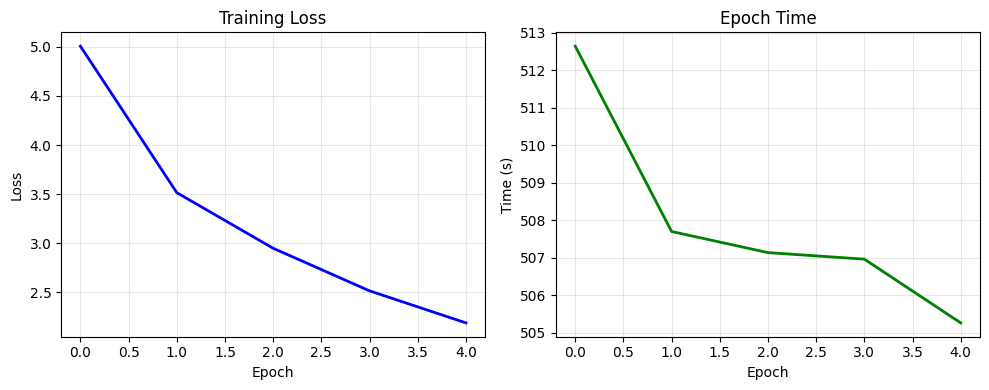

2026-08-24 23:42:32,497 - SSD300_Pipeline - INFO - Training completed successfully in 0:42:24.928347
2026-08-24 23:42:32,498 - SSD300_Pipeline - INFO - Final loss: 2.1891



🎉 Training completed successfully!
   Total time: 0:42:24.928347
   Final loss: 2.1891
   Best loss: 2.1891


In [37]:
# Training loop with enhanced monitoring
logger.info("Starting training...")
training_metrics['start_time'] = datetime.now()

print(f"🚀 Starting SSD300 training...")
print(f"   Epochs: {CONFIG['num_epochs']}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Learning rate: {CONFIG['learning_rate']}")
print(f"   Device: {CONFIG['device']}")
print(f"   Estimated time: {CONFIG['num_epochs'] * len(train_loader) * CONFIG['batch_size'] / 100:.1f} - {CONFIG['num_epochs'] * len(train_loader) * CONFIG['batch_size'] / 50:.1f} minutes")

best_loss = float('inf')

try:
    for epoch in range(CONFIG['num_epochs']):
        logger.info(f"Starting epoch {epoch + 1}/{CONFIG['num_epochs']}")
        print(f"\n📊 Epoch {epoch + 1}/{CONFIG['num_epochs']}")
        
        # Train for one epoch
        epoch_loss = train_one_epoch(model, train_loader, optimizer, CONFIG['device'], epoch)
        
        # Update learning rate tracking
        current_lr = optimizer.param_groups[0]['lr']
        training_metrics['learning_rates'].append(current_lr)
        
        # Save checkpoint
        if CONFIG['save_checkpoints'] and (epoch + 1) % CONFIG['checkpoint_every'] == 0:
            checkpoint_path = f"{CONFIG['output_dir']}/models/ssd300_epoch_{epoch + 1}.pth"
            is_best = epoch_loss < best_loss
            if is_best:
                best_loss = epoch_loss
            
            save_checkpoint(model, optimizer, epoch + 1, epoch_loss, checkpoint_path, is_best)
        
        # Print epoch summary
        print(f"   ✅ Epoch {epoch + 1} completed")
        print(f"   📉 Loss: {epoch_loss:.4f}")
        print(f"   ⏱️  Time: {training_metrics['epoch_times'][-1]:.1f}s")
        print(f"   📚 Learning Rate: {current_lr:.6f}")
        
        # Early visualization of training progress
        if (epoch + 1) % 2 == 0 or epoch == CONFIG['num_epochs'] - 1:
            clear_output(wait=True)
            print(f"Training Progress Update - Epoch {epoch + 1}/{CONFIG['num_epochs']}")
            if len(training_metrics['train_losses']) > 1:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.plot(training_metrics['train_losses'], 'b-', linewidth=2)
                plt.title('Training Loss')
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                plt.grid(True, alpha=0.3)
                
                plt.subplot(1, 2, 2)
                plt.plot(training_metrics['epoch_times'], 'g-', linewidth=2)
                plt.title('Epoch Time')
                plt.xlabel('Epoch')
                plt.ylabel('Time (s)')
                plt.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
    
    training_metrics['end_time'] = datetime.now()
    total_training_time = training_metrics['end_time'] - training_metrics['start_time']
    
    print(f"\n🎉 Training completed successfully!")
    print(f"   Total time: {total_training_time}")
    print(f"   Final loss: {training_metrics['train_losses'][-1]:.4f}")
    print(f"   Best loss: {best_loss:.4f}")
    
    logger.info(f"Training completed successfully in {total_training_time}")
    logger.info(f"Final loss: {training_metrics['train_losses'][-1]:.4f}")
    
except Exception as e:
    training_metrics['end_time'] = datetime.now()
    logger.error(f"Training failed: {e}")
    print(f"❌ Training failed: {e}")
    raise e

## 14. Model Evaluation

In [38]:
# Evaluate the trained model
logger.info("Starting model evaluation...")

print(f"🔍 Evaluating trained model...")

try:
    # Load ground truth COCO for evaluation
    coco_gt = COCO(CONFIG['coco_file'])
    
    # Evaluate on validation set
    eval_metrics = evaluate_model(model, val_loader, CONFIG['device'], coco_gt)
    
    if eval_metrics:
        training_metrics['final_metrics'] = eval_metrics
        training_metrics['best_map'] = eval_metrics.get('mAP_0.5', 0.0)
        
        print(f"\n📊 Evaluation Results:")
        print(f"   mAP@0.5-0.95: {eval_metrics.get('mAP_0.5_0.95', 0):.4f}")
        print(f"   mAP@0.5: {eval_metrics.get('mAP_0.5', 0):.4f}")
        print(f"   mAP@0.75: {eval_metrics.get('mAP_0.75', 0):.4f}")
        print(f"   AR@100: {eval_metrics.get('AR_100', 0):.4f}")
        
        logger.info(f"Evaluation completed - mAP@0.5: {eval_metrics.get('mAP_0.5', 0):.4f}")
    else:
        print(f"⚠️  Evaluation completed but no metrics generated")
        logger.warning("Evaluation completed but no metrics generated")
        
except Exception as e:
    logger.error(f"Evaluation failed: {e}")
    print(f"❌ Evaluation failed: {e}")

2026-08-24 23:42:32,509 - SSD300_Pipeline - INFO - Starting model evaluation...
2026-08-24 23:42:32,636 - SSD300_Pipeline - INFO - Starting model evaluation...


🔍 Evaluating trained model...
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


2026-08-24 23:42:32,786 - SSD300_Pipeline - INFO - Evaluation batch 1/577
2026-08-24 23:42:34,805 - SSD300_Pipeline - INFO - Evaluation batch 21/577
2026-08-24 23:42:36,556 - SSD300_Pipeline - INFO - Evaluation batch 41/577
2026-08-24 23:42:38,697 - SSD300_Pipeline - INFO - Evaluation batch 61/577
2026-08-24 23:42:40,468 - SSD300_Pipeline - INFO - Evaluation batch 81/577
2026-08-24 23:42:42,241 - SSD300_Pipeline - INFO - Evaluation batch 101/577
2026-08-24 23:42:44,057 - SSD300_Pipeline - INFO - Evaluation batch 121/577
2026-08-24 23:42:45,822 - SSD300_Pipeline - INFO - Evaluation batch 141/577
2026-08-24 23:42:47,595 - SSD300_Pipeline - INFO - Evaluation batch 161/577
2026-08-24 23:42:49,360 - SSD300_Pipeline - INFO - Evaluation batch 181/577
2026-08-24 23:42:51,131 - SSD300_Pipeline - INFO - Evaluation batch 201/577
2026-08-24 23:42:52,916 - SSD300_Pipeline - INFO - Evaluation batch 221/577
2026-08-24 23:42:54,690 - SSD300_Pipeline - INFO - Evaluation batch 241/577
2026-08-24 23:42:5

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.76s).
Accumulating evaluation results...
DONE (t=0.98s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

2026-08-24 23:43:38,821 - SSD300_Pipeline - INFO - COCO Evaluation Results:
2026-08-24 23:43:38,822 - SSD300_Pipeline - INFO -   mAP_0.5_0.95: 0.0005
2026-08-24 23:43:38,823 - SSD300_Pipeline - INFO -   mAP_0.5: 0.0020
2026-08-24 23:43:38,824 - SSD300_Pipeline - INFO -   mAP_0.75: 0.0001
2026-08-24 23:43:38,824 - SSD300_Pipeline - INFO -   AP_small: 0.0001
2026-08-24 23:43:38,826 - SSD300_Pipeline - INFO -   AP_medium: 0.0001
2026-08-24 23:43:38,826 - SSD300_Pipeline - INFO -   AP_large: 0.0007
2026-08-24 23:43:38,827 - SSD300_Pipeline - INFO -   AR_1: 0.0011
2026-08-24 23:43:38,828 - SSD300_Pipeline - INFO -   AR_10: 0.0015
2026-08-24 23:43:38,829 - SSD300_Pipeline - INFO -   AR_100: 0.0015
2026-08-24 23:43:38,830 - SSD300_Pipeline - INFO -   AR_small: 0.0002
2026-08-24 23:43:38,831 - SSD300_Pipeline - INFO -   AR_medium: 0.0003
2026-08-24 23:43:38,831 - SSD300_Pipeline - INFO -   AR_large: 0.0020
2026-08-24 23:43:38,832 - SSD300_Pipeline - INFO -   precision: 0.0447
2026-08-24 23:43:


📊 Evaluation Results:
   mAP@0.5-0.95: 0.0005
   mAP@0.5: 0.0020
   mAP@0.75: 0.0001
   AR@100: 0.0015


## 14.5. Inference Speed Benchmarking

In [39]:
# Benchmark inference speed using the shared timing harness (P0:
# benchmark_common.speed_bench -- this notebook previously had NO speed
# benchmarking at all). Images are pre-loaded into memory before timing
# starts, so disk I/O is excluded from the reported numbers.
# Note: torchvision's detection heads apply NMS internally as part of the
# forward pass in eval mode, so "postprocessing" here is the confidence-
# threshold filter this notebook already applies to raw model output elsewhere.
logger.info("Benchmarking inference speed...")

try:
    import glob
    from torchvision.transforms.functional import to_tensor

    _bench_image_paths = sorted(glob.glob(f"{CONFIG['voc_root']}/JPEGImages/*.jpg"))[:protocol.TIMED_ITERS]
    _bench_images = [Image.open(p).convert('RGB') for p in _bench_image_paths]

    def _ssd_preprocess(pil_img):
        return to_tensor(pil_img).unsqueeze(0).to(CONFIG['device'])

    def _ssd_infer(tensor_img):
        with torch.no_grad():
            return model(tensor_img)

    def _ssd_postprocess(raw_output):
        scores = raw_output[0]['scores']
        return scores[scores >= protocol.CONF_THRESHOLD]

    speed_metrics = speed_bench.benchmark_speed(
        _ssd_preprocess, _ssd_infer, _ssd_postprocess, _bench_images, CONFIG['device'],
        warmup_iters=protocol.WARMUP_ITERS, timed_iters=protocol.TIMED_ITERS
    )
    fps = speed_metrics['fps_latency']

    all_metrics = {
        "mAP_0.5_0.95": training_metrics['final_metrics'].get('mAP_0.5_0.95', 0.0),
        "mAP_0.5": training_metrics['final_metrics'].get('mAP_0.5', 0.0),
        "mAP_0.75": training_metrics['final_metrics'].get('mAP_0.75', 0.0),
        "precision": training_metrics['final_metrics'].get('precision', 0.0),
        "recall": training_metrics['final_metrics'].get('recall', 0.0),
        "f1": training_metrics['final_metrics'].get('f1', 0.0),
        "FPS": fps,
        "speed_metrics": speed_metrics
    }

    metrics_file = f"{CONFIG['output_dir']}/predictions/ssd300_metrics.json"
    with open(metrics_file, 'w') as f:
        json.dump(all_metrics, f, indent=2)

    print(f"\n⚡ Performance Summary:")
    print(f"   Preprocessing: {speed_metrics['preprocessing_ms']:.2f} ms")
    print(f"   Inference: {speed_metrics['inference_ms']:.2f} ms")
    print(f"   Postprocessing: {speed_metrics['postprocessing_ms']:.2f} ms")
    print(f"   Latency FPS: {fps:.1f} | Throughput FPS: {speed_metrics['fps_throughput']:.1f}")
    print(f"   Metrics saved to: {metrics_file}")

    logger.info(f"Speed benchmarking completed - Latency FPS: {fps:.1f}")

except Exception as e:
    logger.error(f"Speed benchmarking failed: {e}")
    print(f"⚠️ Speed benchmarking failed: {e}")


2026-08-24 23:43:38,886 - SSD300_Pipeline - INFO - Benchmarking inference speed...
2026-08-24 23:43:43,494 - SSD300_Pipeline - INFO - Speed benchmarking completed - Latency FPS: 40.7



⚡ Performance Summary:
   Preprocessing: 1.65 ms
   Inference: 22.82 ms
   Postprocessing: 0.14 ms
   Latency FPS: 40.7 | Throughput FPS: 40.7
   Metrics saved to: /kaggle/working/ssd300_outputs/predictions/ssd300_metrics.json


## 15. Training Progress Visualization

2026-08-24 23:43:43,501 - SSD300_Pipeline - INFO - Creating training progress visualization...
2026-08-24 23:43:45,102 - SSD300_Pipeline - INFO - Training progress plot saved to /kaggle/working/ssd300_outputs/visualizations/training_progress.png


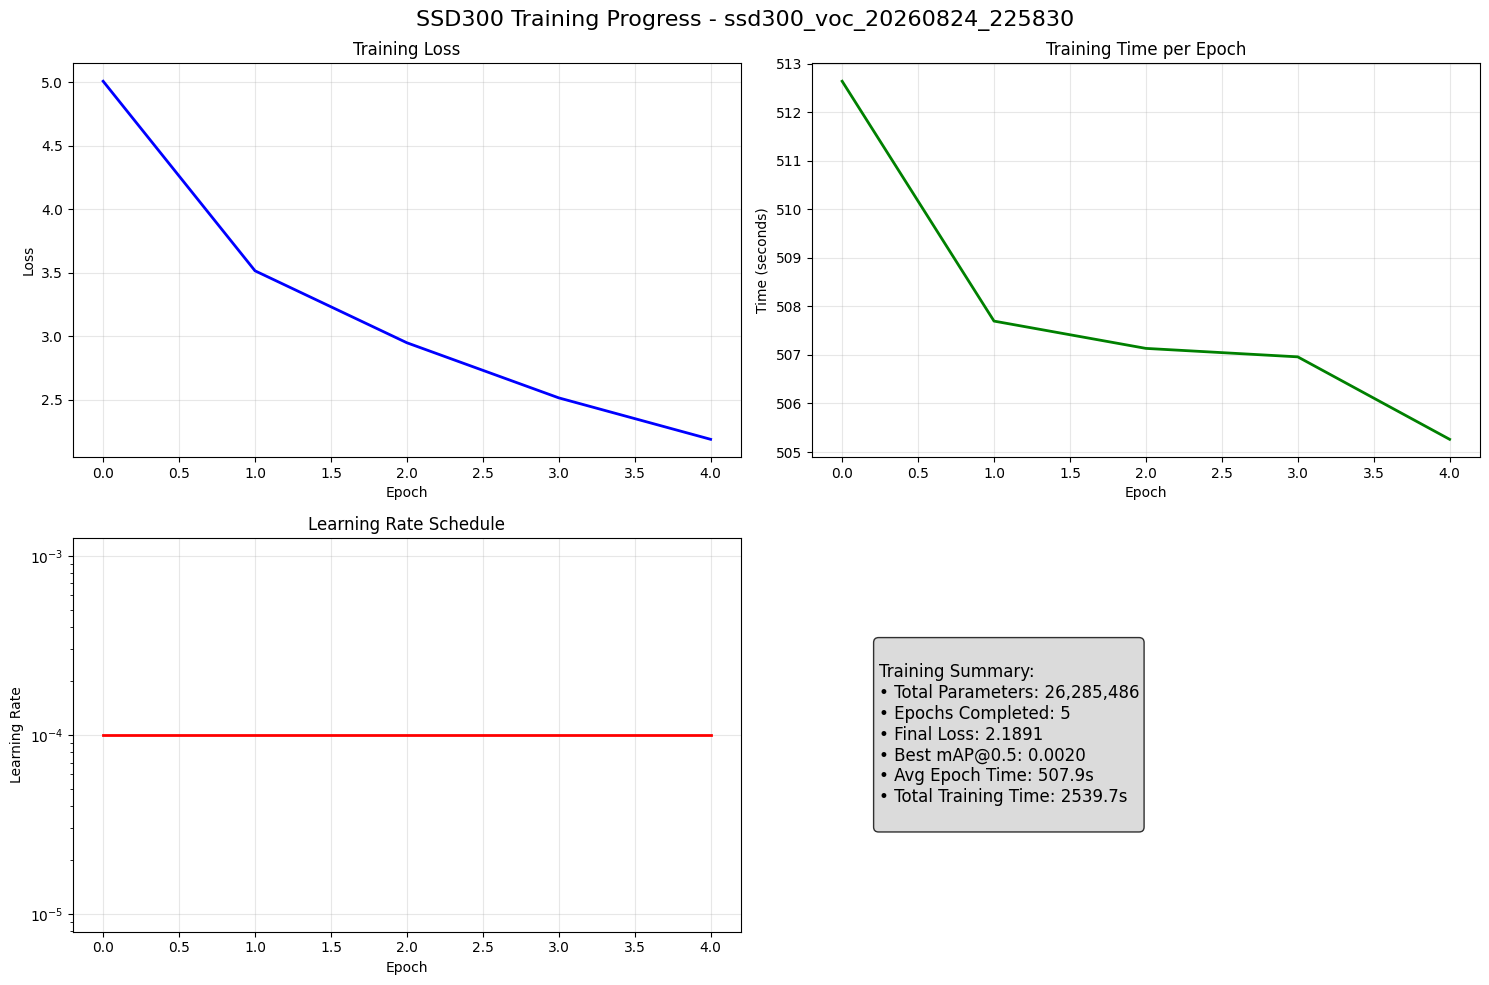

✅ Training visualization saved to /kaggle/working/ssd300_outputs/visualizations/training_progress.png


In [40]:
# Create comprehensive training visualization
if CONFIG['save_visualizations']:
    logger.info("Creating training progress visualization...")
    
    viz_path = f"{CONFIG['output_dir']}/visualizations/training_progress.png"
    visualize_training_progress(training_metrics, viz_path)
    
    print(f"✅ Training visualization saved to {viz_path}")

## 16. Sample Predictions Visualization

2026-08-24 23:43:45,555 - SSD300_Pipeline - INFO - Creating sample predictions visualization...
2026-08-24 23:43:47,970 - SSD300_Pipeline - INFO - Prediction visualization saved to /kaggle/working/ssd300_outputs/visualizations/sample_predictions.png


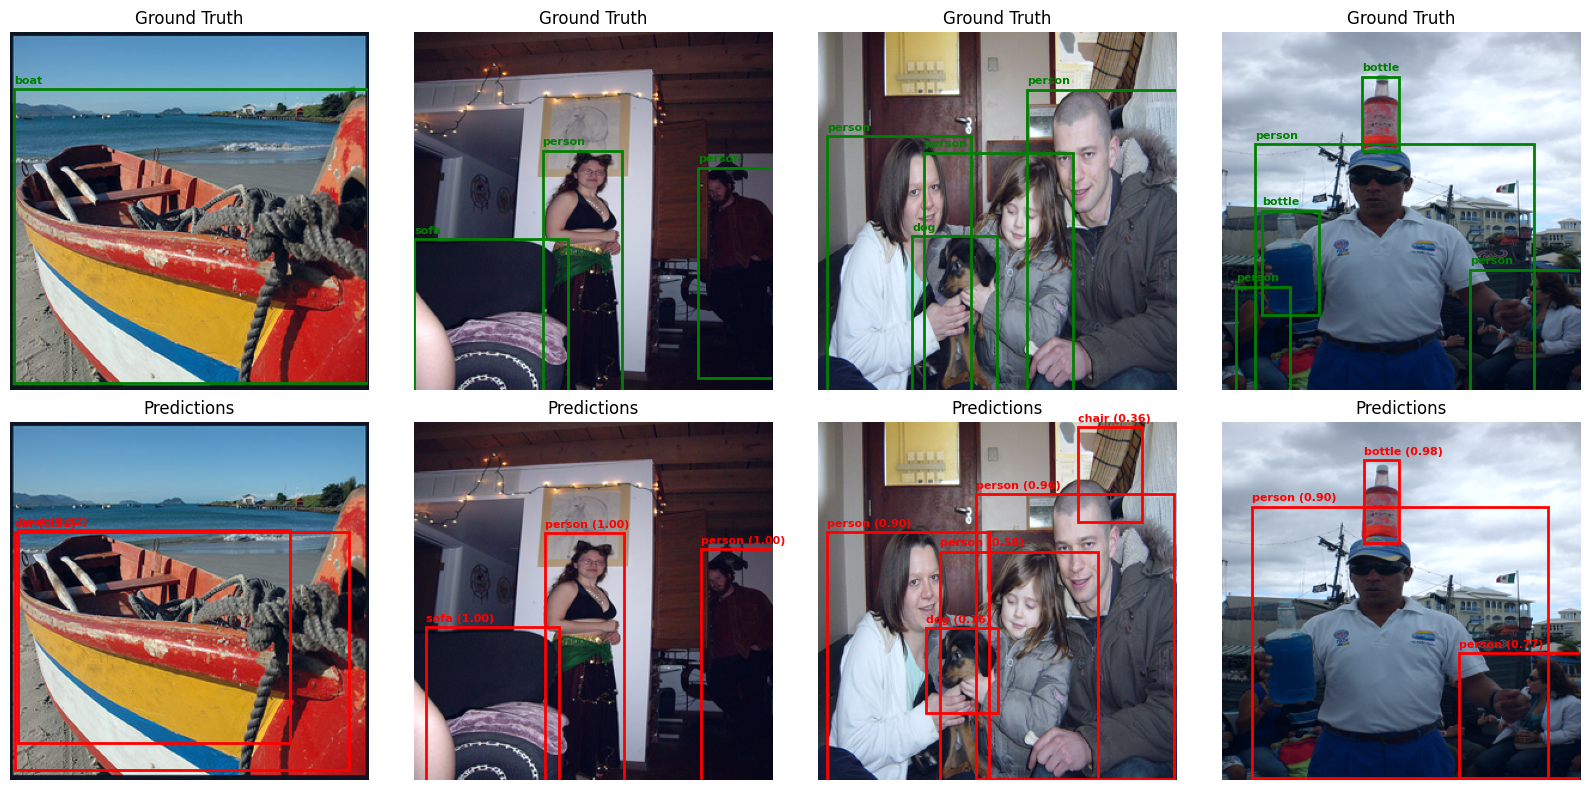

✅ Sample predictions visualization saved to /kaggle/working/ssd300_outputs/visualizations/sample_predictions.png


In [41]:
# Visualize sample predictions
if CONFIG['save_visualizations']:
    logger.info("Creating sample predictions visualization...")
    
    pred_viz_path = f"{CONFIG['output_dir']}/visualizations/sample_predictions.png"
    visualize_predictions(model, dataset, CONFIG['device'], num_images=4, save_path=pred_viz_path)
    
    print(f"✅ Sample predictions visualization saved to {pred_viz_path}")

## 17. Comparison Images Testing

2026-08-24 23:43:48,989 - SSD300_Pipeline - INFO - Testing on comparison images...
2026-08-24 23:43:48,992 - SSD300_Pipeline - INFO - Testing on 20 comparison images...


🖼️  Testing on comparison images...
Loaded comparison manifest: /kaggle/working/object-detection-benchmarking-and-analysis/comparison_images.json -- 20/20 images


2026-08-24 23:45:20,964 - SSD300_Pipeline - INFO - Found 3 comparison images in dataset
2026-08-24 23:45:22,605 - SSD300_Pipeline - INFO - Comparison visualization saved to /kaggle/working/ssd300_outputs/visualizations/comparison_predictions.png


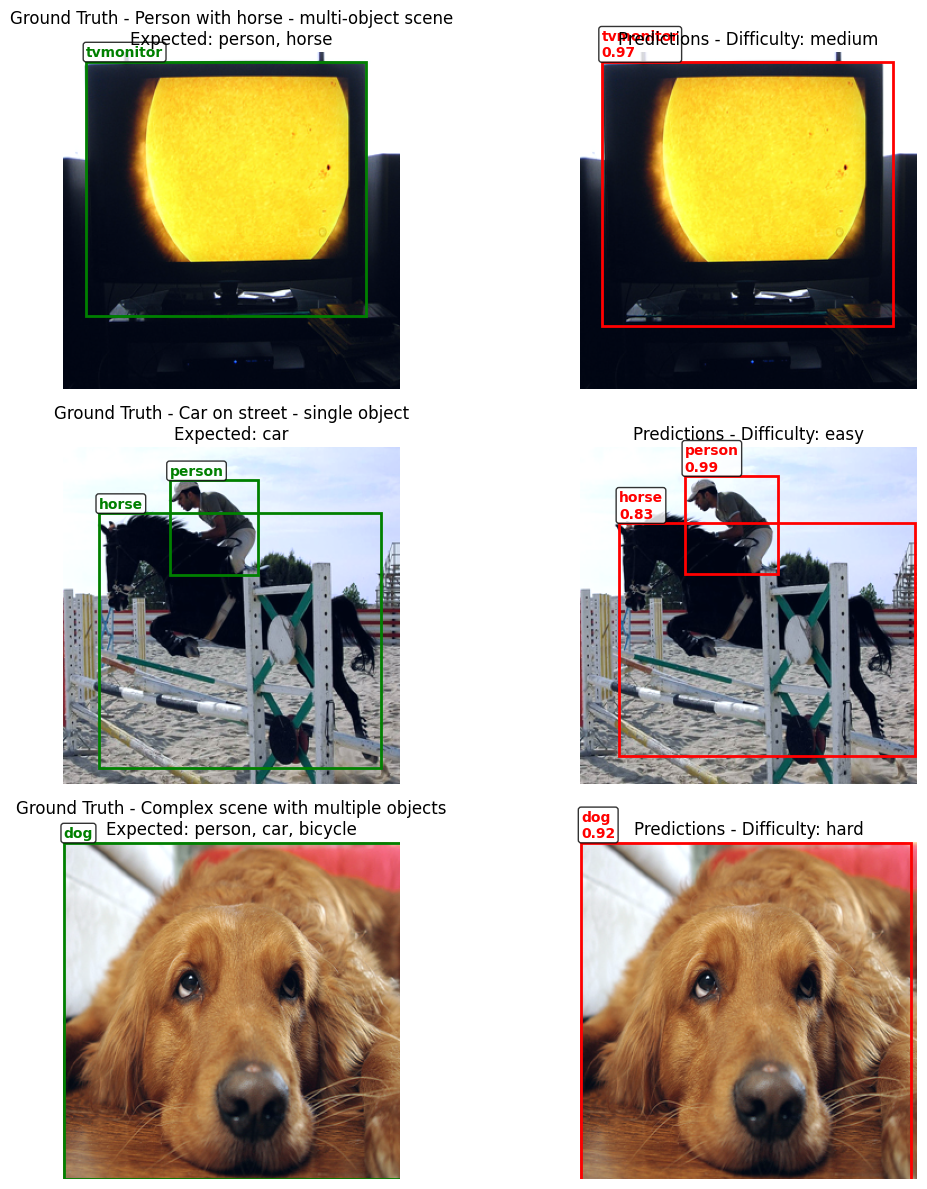

2026-08-24 23:45:23,167 - SSD300_Pipeline - INFO - Comparison results saved to /kaggle/working/ssd300_outputs/predictions/comparison_results.json
2026-08-24 23:45:23,170 - SSD300_Pipeline - INFO - Comparison testing completed on 3 images



🎯 Comparison Images Results Summary:

📷 2008_000002.jpg (medium)
   Expected: person, horse
   Predicted: tvmonitor
   Overlap: None
   Avg Confidence: 0.971

📷 2008_000008.jpg (easy)
   Expected: car
   Predicted: person, horse
   Overlap: None
   Avg Confidence: 0.913

📷 2008_001430.jpg (hard)
   Expected: bicycle, person, car
   Predicted: dog
   Overlap: None
   Avg Confidence: 0.923

✅ Comparison testing completed!
   Tested images: 3


In [42]:
# Test on comparison images (P0: benchmark_common.comparison -- fail-loud
# shared manifest, no silent fallback to a smaller default set)
if CONFIG['run_comparison_images']:
    logger.info("Testing on comparison images...")

    print(f"🖼️  Testing on comparison images...")

    comparison_manifest = comparison.load_comparison_manifest([
        '/kaggle/input/comparison-images/comparison_images.json',
        '/kaggle/working/comparison_images.json',
        './comparison_images.json',
        '../comparison_images.json',
        str(_REPO_ROOT / 'comparison_images.json'),
    ])

    try:
        comparison_results = test_comparison_images(model, dataset, CONFIG['device'], comparison_manifest)

        print(f"\n✅ Comparison testing completed!")
        print(f"   Tested images: {len(comparison_results)}")

        logger.info(f"Comparison testing completed on {len(comparison_results)} images")

    except Exception as e:
        logger.error(f"Comparison testing failed: {e}")
        print(f"❌ Comparison testing failed: {e}")
else:
    print(f"⏭️  Skipping comparison images testing (disabled in config)")


## 18. Final Report Generation

In [43]:
# Generate comprehensive final report
logger.info("Generating final report...")

final_report = {
    'experiment_info': {
        'name': CONFIG['experiment_name'],
        'timestamp': datetime.now().isoformat(),
        'model': 'SSD300',
        'backbone': 'VGG16',
        'dataset': 'Pascal VOC 2012',
        'device': CONFIG['device']
    },
    'environment_info': environment_info,
    'configuration': CONFIG,
    'training_metrics': training_metrics,
    'dataset_info': {
        'total_samples': len(dataset) if 'dataset' in locals() else 0,
        'train_samples': len(train_dataset) if 'train_dataset' in locals() else 0,
        'val_samples': len(val_dataset) if 'val_dataset' in locals() else 0,
        'num_classes': len(VOC_CLASSES),
        'classes': VOC_CLASSES
    },
    'model_info': {
        'total_parameters': training_metrics['total_parameters'],
        'model_size_mb': training_metrics['model_size_mb'],
        'optimizer': 'Adam',
        'learning_rate': CONFIG['learning_rate']
    },
    'output_files': {
        'log_file': f"{CONFIG['output_dir']}/logs/{CONFIG['experiment_name']}.log",
        'final_model': f"{CONFIG['output_dir']}/models/ssd300_epoch_{CONFIG['num_epochs']}.pth",
        'best_model': f"{CONFIG['output_dir']}/models/ssd300_epoch_{CONFIG['num_epochs']}_best.pth",
        'predictions': f"{CONFIG['output_dir']}/predictions/ssd300_predictions.json",
        'comparison_results': f"{CONFIG['output_dir']}/predictions/comparison_results.json",
        'training_viz': f"{CONFIG['output_dir']}/visualizations/training_progress.png",
        'predictions_viz': f"{CONFIG['output_dir']}/visualizations/sample_predictions.png",
        'comparison_viz': f"{CONFIG['output_dir']}/visualizations/comparison_predictions.png"
    }
}

# Save final report
report_file = f"{CONFIG['output_dir']}/{CONFIG['experiment_name']}_final_report.json"
with open(report_file, 'w') as f:
    json.dump(final_report, f, indent=2, default=str)

# Save final model
final_model_path = f"{CONFIG['output_dir']}/models/ssd300_final.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'training_metrics': training_metrics,
    'final_report': final_report
}, final_model_path)

print(f"\n🎉 SSD300 Pipeline Completed Successfully!")
print(f"\n📋 Final Summary:")
print(f"   Experiment: {CONFIG['experiment_name']}")
print(f"   Device: {CONFIG['device']}")
print(f"   Training time: {training_metrics['end_time'] - training_metrics['start_time']}")
print(f"   Epochs completed: {len(training_metrics['train_losses'])}/{CONFIG['num_epochs']}")
print(f"   Final loss: {training_metrics['train_losses'][-1]:.4f}")
if training_metrics['best_map'] > 0:
    print(f"   Best mAP@0.5: {training_metrics['best_map']:.4f}")
print(f"   Model size: {training_metrics['model_size_mb']:.1f} MB")
print(f"   Parameters: {training_metrics['total_parameters']:,}")

print(f"\n📁 Output Files:")
print(f"   📊 Final report: {report_file}")
print(f"   🤖 Final model: {final_model_path}")
print(f"   📝 Training log: {log_file}")
print(f"   📈 Visualizations: {CONFIG['output_dir']}/visualizations/")
print(f"   🎯 Predictions: {CONFIG['output_dir']}/predictions/")

logger.info(f"SSD300 pipeline completed successfully!")
logger.info(f"Final report saved to {report_file}")
logger.info(f"Final model saved to {final_model_path}")
logger.info("=== EXPERIMENT COMPLETED ===")

print(f"\n✨ All done! Check the output directory for all generated files.")
print(f"\n\u26a0\ufe0f  Kaggle sessions are ephemeral -- click 'Save Version' now, or download ")
print(f"   {CONFIG['output_dir']} manually, or these results will be lost when the session ends.")

2026-08-24 23:45:23,183 - SSD300_Pipeline - INFO - Generating final report...
2026-08-24 23:45:23,616 - SSD300_Pipeline - INFO - SSD300 pipeline completed successfully!
2026-08-24 23:45:23,617 - SSD300_Pipeline - INFO - Final report saved to /kaggle/working/ssd300_outputs/ssd300_voc_20260824_225830_final_report.json
2026-08-24 23:45:23,619 - SSD300_Pipeline - INFO - Final model saved to /kaggle/working/ssd300_outputs/models/ssd300_final.pth
2026-08-24 23:45:23,619 - SSD300_Pipeline - INFO - === EXPERIMENT COMPLETED ===



🎉 SSD300 Pipeline Completed Successfully!

📋 Final Summary:
   Experiment: ssd300_voc_20260824_225830
   Device: cuda
   Training time: 0:42:24.928347
   Epochs completed: 5/5
   Final loss: 2.1891
   Best mAP@0.5: 0.0020
   Model size: 100.3 MB
   Parameters: 26,285,486

📁 Output Files:
   📊 Final report: /kaggle/working/ssd300_outputs/ssd300_voc_20260824_225830_final_report.json
   🤖 Final model: /kaggle/working/ssd300_outputs/models/ssd300_final.pth
   📝 Training log: /kaggle/working/ssd300_outputs/logs/ssd300_voc_20260824_225830.log
   📈 Visualizations: /kaggle/working/ssd300_outputs/visualizations/
   🎯 Predictions: /kaggle/working/ssd300_outputs/predictions/

✨ All done! Check the output directory for all generated files.

⚠️  Kaggle sessions are ephemeral -- click 'Save Version' now, or download 
   /kaggle/working/ssd300_outputs manually, or these results will be lost when the session ends.
